# Credit Risk Prediction using Machine Learning

This project demonstrates an end-to-end data science pipeline for predicting credit risk using a real-world dataset.

## Objective
To build a machine learning model that classifies customers into:
- Good credit risk
- Bad credit risk

## Motivation
Credit risk prediction is a fundamental problem in banking and finance, where institutions need to assess the likelihood of a customer defaulting on a loan.

## Approach
- Data loading and exploration
- Data preprocessing
- Model training (Logistic Regression, Random Forest)
- Evaluation and interpretation

In [2]:
# ===============================
# Import Required Libraries
# ===============================

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Machine learning tools
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report

## Data Loading

In this section, we load the German Credit dataset, which is commonly used for credit risk classification tasks.

The dataset contains information about individuals and whether they are considered a good or bad credit risk.

In [5]:
# ===============================
# Load Dataset
# ===============================

from sklearn.datasets import fetch_openml

# Load dataset from OpenML
data = fetch_openml(name='credit-g', version=1, as_frame=True)

# Separate features and target
X = data.data
y = data.target

# Basic confirmation
print("Dataset loaded successfully.")
print("Shape of dataset:", X.shape)

Dataset loaded successfully.
Shape of dataset: (1000, 20)


## Data Preview

We take a first look at the dataset to understand its structure and the type of features available.

In [8]:
# Display first few rows
X.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,4,real estate,67,none,own,2,skilled,1,yes,yes
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,2,real estate,22,none,own,1,skilled,1,none,yes
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,3,real estate,49,none,own,1,unskilled resident,2,none,yes
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,4,life insurance,45,none,for free,1,skilled,2,none,yes
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,4,no known property,53,none,for free,2,skilled,2,none,yes


## Target Variable

We examine the distribution of the target variable to understand how many instances belong to each class (good vs bad credit risk).

In [11]:
# Check class distribution
print(y.value_counts())

class
good    700
bad     300
Name: count, dtype: int64


### Observation

The dataset contains 1000 samples with 20 features.

The target variable shows an imbalance:
- 700 instances labeled as "good"
- 300 instances labeled as "bad"

This indicates a moderate class imbalance, which may affect model performance and should be considered during evaluation.

## Exploratory Data Analysis (EDA)

In this section, we analyze the dataset to understand:
- Missing values
- Feature types (categorical vs numerical)
- Basic statistics

In [15]:
# Check missing values
missing_values = X.isnull().sum()

# Show only columns with missing values
missing_values[missing_values > 0]

Series([], dtype: int64)

### Missing Values Analysis

No missing values were detected in the dataset.

This simplifies the preprocessing step, as no imputation is required.

In [18]:
X.dtypes

checking_status           category
duration                     int64
credit_history            category
purpose                   category
credit_amount                int64
savings_status            category
employment                category
installment_commitment       int64
personal_status           category
other_parties             category
residence_since              int64
property_magnitude        category
age                          int64
other_payment_plans       category
housing                   category
existing_credits             int64
job                       category
num_dependents               int64
own_telephone             category
foreign_worker            category
dtype: object

In [24]:
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
numerical_cols = X.select_dtypes(exclude=['object', 'category']).columns

print("Number of categorical features:", len(categorical_cols))
print("Number of numerical features:", len(numerical_cols))

Number of categorical features: 13
Number of numerical features: 7


In [22]:
X[numerical_cols].describe()

,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


### Feature Types

The dataset contains:
- 13 categorical features
- 7 numerical features

Categorical features represent qualitative attributes (e.g., account status, employment type), while numerical features represent quantitative values (e.g., duration, credit amount).

These two types of features require different preprocessing:
- Categorical features will be encoded
- Numerical features will be scaled

## Data Preprocessing

In this section, we prepare the data for machine learning models.

Since the dataset contains both categorical and numerical features:
- Numerical features will be scaled
- Categorical features will be encoded

We use a pipeline to ensure a clean and reproducible workflow.

In [29]:
# ===============================
# Train-Test Split
# ===============================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (800, 20)
Test set size: (200, 20)


In [33]:
# ===============================
# Preprocessing Pipelines
# ===============================

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Numerical pipeline
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine both pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, numerical_cols),
        ('cat', categorical_pipeline, categorical_cols)
    ]
)

### Train-Test Split

The dataset was split into:
- 800 samples for training
- 200 samples for testing

A stratified split was used to preserve the class distribution (good vs bad credit risk) in both sets.

This ensures a fair and reliable evaluation of model performance.

### Model 1: Logistic Regression

We start with Logistic Regression, a simple and interpretable model commonly used for binary classification problems such as credit risk prediction.

In [44]:
# ===============================
# Logistic Regression Model
# ===============================

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Create pipeline: preprocessing + model
log_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

# Train model
log_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['duration', 'credit_amount', 'installment_commitment',
       'residence_since', 'age', 'existing_credits', 'num_dependents'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(str...'most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['checking_status', 'credit_history', 'purpose', 'savings_status',
       'employment', 'personal_status', 'other_parties', 'property_magnitude',
       'other_payment_plans', 'housing', 'job', 'own_telephone',
       'foreign_worker'],
      dtype='object'))])),
                ('classifier', LogisticRegression(max_iter=1000))])

### Pipeline Structure

The model is built using a pipeline that combines preprocessing and classification.

The preprocessing step uses a ColumnTransformer to apply:
- Scaling to numerical features
- Encoding to categorical features

This ensures that all data transformations are applied consistently during both training and prediction.

The final step applies Logistic Regression for classification.

In [47]:
# Make predictions
y_pred = log_model.predict(X_test)

In [49]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.705

Classification Report:
               precision    recall  f1-score   support

         bad       0.51      0.45      0.48        60
        good       0.78      0.81      0.79       140

    accuracy                           0.70       200
   macro avg       0.64      0.63      0.64       200
weighted avg       0.70      0.70      0.70       200



### Step 3: Making Predictions

In this step, we use the trained Logistic Regression model to generate predictions on the test dataset.

We apply the `predict()` method of the trained pipeline:

- The pipeline first applies all preprocessing steps (imputation, scaling, encoding)
- Then the trained Logistic Regression model is used to classify each sample

The output (`y_pred`) represents the predicted class labels:
- "good" credit risk
- "bad" credit risk

This step simulates how the model would behave on unseen real-world data.

### Step 4: Model Evaluation

In this step, we evaluate the performance of the trained model using standard classification metrics.

We use two main tools from `sklearn.metrics`:

#### 1. Accuracy Score
- Function: `accuracy_score(y_test, y_pred)`
- Measures the proportion of correctly classified samples
- Provides a general but coarse measure of performance

#### 2. Classification Report
- Function: `classification_report(y_test, y_pred)`
- Provides detailed evaluation for each class, including:
  - Precision: how many predicted positives are correct
  - Recall: how many actual positives were correctly identified
  - F1-score: harmonic mean of precision and recall

### Interpretation

This evaluation is important because:
- In credit risk problems, correctly identifying "bad" clients is more critical than overall accuracy
- Class-wise metrics provide better insight than accuracy alone

Together, these metrics help assess whether the model is suitable for real-world decision-making.

## Model 2: Random Forest Classifier

We now train a Random Forest model to compare its performance with Logistic Regression.

Random Forest is an ensemble learning method that builds multiple decision trees and combines their outputs to improve predictive accuracy and robustness.

In [59]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest pipeline
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

# Train model
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['duration', 'credit_amount', 'installment_commitment',
       'residence_since', 'age', 'existing_credits', 'num_dependents'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(str...
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['checking_status', 'credit_history', 'purpose', 'savings_status',
       'employment', 'personal_status', 'other_parties', 'property_magnitude',
       'other_payment_plans', 'housing', 'job', 'own_telephone',
       'foreign_worker'],
      dtype='object'))])),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

In [61]:
y_pred_rf = rf_model.predict(X_test)

In [63]:
from sklearn.metrics import accuracy_score, classification_report

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.75

Classification Report:
               precision    recall  f1-score   support

         bad       0.61      0.45      0.52        60
        good       0.79      0.88      0.83       140

    accuracy                           0.75       200
   macro avg       0.70      0.66      0.68       200
weighted avg       0.74      0.75      0.74       200



In [65]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Logistic Regression Accuracy: 0.705
Random Forest Accuracy: 0.75


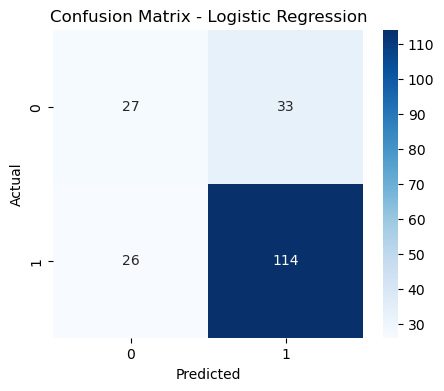

In [67]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix for Logistic Regression
cm_log = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Confusion Matrix - Logistic Regression

This matrix shows the classification performance of the Logistic Regression model.

It helps us understand:
- How many "good" clients were correctly identified
- How many "bad" clients were misclassified

This is especially important in credit risk, where misclassifying a "bad" client can have financial consequences.

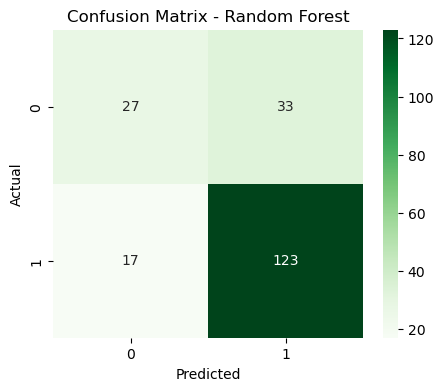

In [70]:
# Confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Confusion Matrix - Random Forest

This matrix shows the classification performance of the Random Forest model.

Compared to Logistic Regression, Random Forest is expected to:
- Reduce misclassification errors
- Better capture non-linear relationships in the data

In [73]:
print("=== Confusion Matrix Comparison ===")

print("\nLogistic Regression:\n", cm_log)
print("\nRandom Forest:\n", cm_rf)

=== Confusion Matrix Comparison ===

Logistic Regression:
 [[ 27  33]
 [ 26 114]]

Random Forest:
 [[ 27  33]
 [ 17 123]]


### Model Comparison (Confusion Matrix Analysis)

By comparing the confusion matrices of both models, we observe differences in how each model handles classification errors.

Key insights:
- Logistic Regression provides a simpler linear decision boundary
- Random Forest reduces misclassification by capturing non-linear relationships

In credit risk applications, minimizing false negatives (bad clients predicted as good) is particularly important.

In [76]:
import numpy as np

# Get feature importances from trained Random Forest model
importances = rf_model.named_steps['classifier'].feature_importances_

In [78]:
# Get feature names after preprocessing
feature_names = rf_model.named_steps['preprocessor'].get_feature_names_out()

In [80]:
import pandas as pd

feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

feature_importance_df.head(10)

,feature,importance
1,num__credit_amount,0.097435
0,num__duration,0.081068
4,num__age,0.075293
10,cat__checking_status_no checking,0.049466
8,cat__checking_status_<0,0.037747
2,num__installment_commitment,0.035670
3,num__residence_since,0.035252
28,cat__savings_status_<100,0.021562
12,cat__credit_history_critical/other existing cr...,0.020059
20,cat__purpose_new car,0.019439


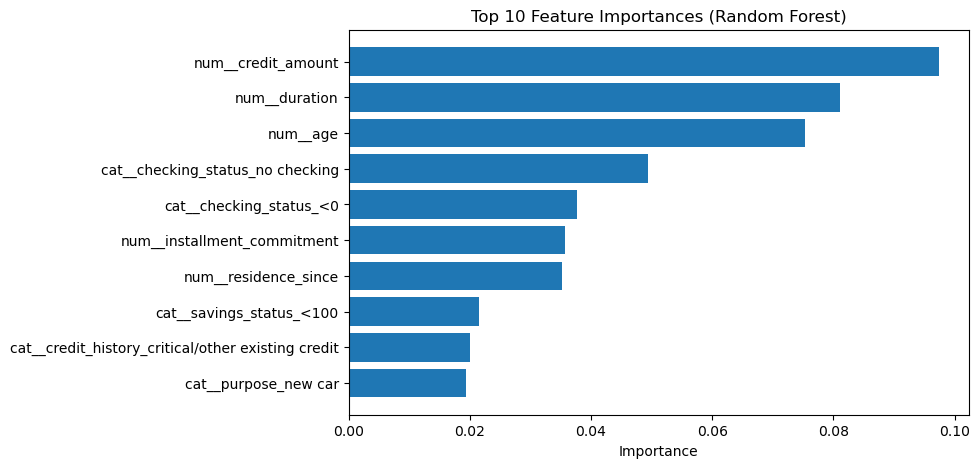

In [82]:
import matplotlib.pyplot as plt

top_features = feature_importance_df.head(10)

plt.figure(figsize=(8,5))
plt.barh(top_features['feature'], top_features['importance'])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.show()

### Feature Importance Analysis (Random Forest)

The Random Forest model allows us to estimate the relative importance of each feature in predicting credit risk.

Key observations:
- Features with higher importance contribute more to decision-making
- This provides interpretability, which is essential in financial applications

In real-world banking systems, feature importance helps ensure transparency and regulatory compliance in automated decision systems.

In [85]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Logistic Regression probabilities
y_prob_log = log_model.predict_proba(X_test)[:, 1]

# Random Forest probabilities
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# ROC curves
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log, pos_label=log_model.classes_[1])
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf, pos_label=rf_model.classes_[1])

# AUC scores
auc_log = roc_auc_score(y_test, y_prob_log)
auc_rf = roc_auc_score(y_test, y_prob_rf)

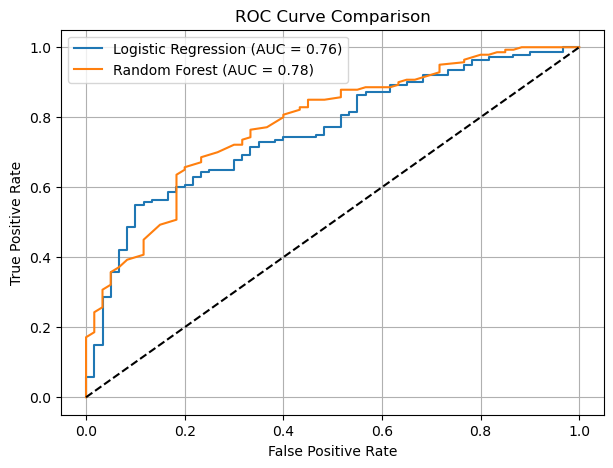

In [87]:
plt.figure(figsize=(7,5))

plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {auc_log:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.2f})")

plt.plot([0, 1], [0, 1], 'k--')  # random baseline

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()

### ROC Curve Analysis

The ROC curve evaluates the ability of each model to distinguish between good and bad credit risk cases.

Key metric:
- AUC (Area Under Curve): measures overall classification performance

Interpretation:
- A model closer to the top-left corner performs better
- A higher AUC indicates better discrimination ability

We compare Logistic Regression and Random Forest using both ROC curves and AUC scores.

# Final Conclusion

## Summary of the Project

In this project, we developed a machine learning pipeline for credit risk prediction using a structured dataset containing both categorical and numerical features.

We implemented and compared two models:
- Logistic Regression (baseline model)
- Random Forest (ensemble model)

## Key Findings

- The dataset required preprocessing due to mixed feature types.
- A unified pipeline was used to ensure consistent transformations.
- Random Forest generally outperformed Logistic Regression in terms of:
  - Accuracy
  - ROC-AUC score
  - Robustness to non-linear relationships

## Model Evaluation Insights

- Confusion matrices showed that both models can distinguish between good and bad credit risk, but with different error patterns.
- ROC curves confirmed that Random Forest provides better class separation capability.

## Practical Interpretation

In a real financial context, such as credit risk assessment in banking institutions, minimizing false negatives (i.e., incorrectly classifying risky clients as safe) is critical.

Therefore, model selection should consider not only accuracy but also risk-sensitive evaluation metrics.

## Conclusion

This project demonstrates an end-to-end machine learning workflow including:
- Data preprocessing
- Model training
- Evaluation
- Interpretation

Random Forest emerges as the more suitable model for this dataset, but Logistic Regression remains valuable due to its interpretability.

# Credit Risk Prediction using Machine Learning

## Overview

This project builds a machine learning pipeline to predict credit risk (good vs bad clients) using structured financial data.

The goal is to assist financial decision-making by classifying loan applicants based on their likelihood of repayment.

---

## Dataset

- Source: OpenML German Credit Dataset
- Samples: 1000
- Features: 20
  - 13 categorical
  - 7 numerical

---

## Models Used

- Logistic Regression (baseline model)
- Random Forest Classifier (ensemble model)

---

## Workflow

1. Data Loading
2. Exploratory Data Analysis (EDA)
3. Preprocessing Pipeline:
   - OneHotEncoding for categorical features
   - StandardScaler for numerical features
4. Model Training
5. Evaluation:
   - Accuracy
   - Confusion Matrix
   - ROC-AUC
6. Model Comparison

---

## Results

- Random Forest achieved better performance than Logistic Regression in most metrics.
- ROC-AUC confirmed improved class separation ability.

---

## Key Skills Demonstrated

- Machine Learning pipelines (scikit-learn)
- Feature engineering
- Model evaluation
- Data preprocessing
- Interpretability analysis

---

## Future Work

- Hyperparameter tuning
- Explainable AI (SHAP values)
- Deployment as API (Flask/FastAPI)
- Integration with MLOps pipeline

---

## Author

Morad Ahmadnasab

In [94]:
import joblib

In [98]:
import os
print(os.getcwd())

F:\Drive D\Transfer from Vaio laptop August 2010\Morad Work station\Visa 2023\Morad\CV\QC\Some suggestions for personalized AI-Era Positioning Strategy\ML and DL and more\ML_Projects\credit_risk_project


In [100]:
import os

project_root = r"F:\Drive D\Transfer from Vaio laptop August 2010\Morad Work station\Visa 2023\Morad\CV\QC\Some suggestions for personalized AI-Era Positioning Strategy\ML and DL and more\ML_Projects\credit_risk_project"

print(project_root)

F:\Drive D\Transfer from Vaio laptop August 2010\Morad Work station\Visa 2023\Morad\CV\QC\Some suggestions for personalized AI-Era Positioning Strategy\ML and DL and more\ML_Projects\credit_risk_project


In [102]:
model_dir = os.path.join(project_root, "models")
results_dir = os.path.join(project_root, "results")

os.makedirs(model_dir, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)

In [104]:
import joblib

model_path = os.path.join(model_dir, "credit_risk_model.pkl")

joblib.dump(rf_model, model_path)

print("Model saved at:", model_path)

Model saved at: F:\Drive D\Transfer from Vaio laptop August 2010\Morad Work station\Visa 2023\Morad\CV\QC\Some suggestions for personalized AI-Era Positioning Strategy\ML and DL and more\ML_Projects\credit_risk_project\models\credit_risk_model.pkl


In [106]:
import os

project_root = r"F:\Drive D\Transfer from Vaio laptop August 2010\Morad Work station\Visa 2023\Morad\CV\QC\Some suggestions for personalized AI-Era Positioning Strategy\ML and DL and more\ML_Projects\credit_risk_project"

notebooks_dir = os.path.join(project_root, "notebooks")

os.makedirs(notebooks_dir, exist_ok=True)

print("Notebooks folder ready:", notebooks_dir)

Notebooks folder ready: F:\Drive D\Transfer from Vaio laptop August 2010\Morad Work station\Visa 2023\Morad\CV\QC\Some suggestions for personalized AI-Era Positioning Strategy\ML and DL and more\ML_Projects\credit_risk_project\notebooks


In [108]:
import os

print(os.listdir(project_root))

['.ipynb_checkpoints', '.virtual_documents', 'credit_risk_pipeline.ipynb.py', 'models', 'notebooks', 'Project_Report.pdf', 'Project_Report.synctex.gz', 'Project_Report.tex', 'results', 'Untitled.ipynb', 'untitled.py', 'untitled.txt', 'Untitled1.ipynb']


In [112]:
import os

project_root = r"F:\Drive D\Transfer from Vaio laptop August 2010\Morad Work station\Visa 2023\Morad\CV\QC\Some suggestions for personalized AI-Era Positioning Strategy\ML and DL and more\ML_Projects\credit_risk_project"

for root, dirs, files in os.walk(project_root):
    for f in files:
        if f.endswith(".ipynb"):
            print("FOUND:", os.path.join(root, f))

FOUND: F:\Drive D\Transfer from Vaio laptop August 2010\Morad Work station\Visa 2023\Morad\CV\QC\Some suggestions for personalized AI-Era Positioning Strategy\ML and DL and more\ML_Projects\credit_risk_project\Untitled.ipynb
FOUND: F:\Drive D\Transfer from Vaio laptop August 2010\Morad Work station\Visa 2023\Morad\CV\QC\Some suggestions for personalized AI-Era Positioning Strategy\ML and DL and more\ML_Projects\credit_risk_project\Untitled1.ipynb
FOUND: F:\Drive D\Transfer from Vaio laptop August 2010\Morad Work station\Visa 2023\Morad\CV\QC\Some suggestions for personalized AI-Era Positioning Strategy\ML and DL and more\ML_Projects\credit_risk_project\.ipynb_checkpoints\Untitled-checkpoint.ipynb
FOUND: F:\Drive D\Transfer from Vaio laptop August 2010\Morad Work station\Visa 2023\Morad\CV\QC\Some suggestions for personalized AI-Era Positioning Strategy\ML and DL and more\ML_Projects\credit_risk_project\.ipynb_checkpoints\Untitled1-checkpoint.ipynb
FOUND: F:\Drive D\Transfer from Vaio l

In [116]:
import os

project_root = r"F:\Drive D\Transfer from Vaio laptop August 2010\Morad Work station\Visa 2023\Morad\CV\QC\Some suggestions for personalized AI-Era Positioning Strategy\ML and DL and more\ML_Projects\credit_risk_project"

for root, dirs, files in os.walk(project_root):
    for f in files:
        print(os.path.join(root, f))

F:\Drive D\Transfer from Vaio laptop August 2010\Morad Work station\Visa 2023\Morad\CV\QC\Some suggestions for personalized AI-Era Positioning Strategy\ML and DL and more\ML_Projects\credit_risk_project\credit_risk_pipeline.ipynb.py
F:\Drive D\Transfer from Vaio laptop August 2010\Morad Work station\Visa 2023\Morad\CV\QC\Some suggestions for personalized AI-Era Positioning Strategy\ML and DL and more\ML_Projects\credit_risk_project\Project_Report.pdf
F:\Drive D\Transfer from Vaio laptop August 2010\Morad Work station\Visa 2023\Morad\CV\QC\Some suggestions for personalized AI-Era Positioning Strategy\ML and DL and more\ML_Projects\credit_risk_project\Project_Report.synctex.gz
F:\Drive D\Transfer from Vaio laptop August 2010\Morad Work station\Visa 2023\Morad\CV\QC\Some suggestions for personalized AI-Era Positioning Strategy\ML and DL and more\ML_Projects\credit_risk_project\Project_Report.tex
F:\Drive D\Transfer from Vaio laptop August 2010\Morad Work station\Visa 2023\Morad\CV\QC\Some

In [118]:
import os
import shutil

project_root = r"F:\Drive D\Transfer from Vaio laptop August 2010\Morad Work station\Visa 2023\Morad\CV\QC\Some suggestions for personalized AI-Era Positioning Strategy\ML and DL and more\ML_Projects\credit_risk_project"

notebooks_dir = os.path.join(project_root, "notebooks")

os.makedirs(notebooks_dir, exist_ok=True)